In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# Read Excel file
df = pd.read_excel("Forecast of the Dinner Meal.xlsx", sheet_name="Sheet1")

df.head()



,Trend,Year,Cost
0,1,2017,75.76
1,2,2018,78.34
2,3,2019,81.64
3,4,2020,85.17
4,5,2021,87.56


Forecasted Costs:
   Trend  Year  Forecast_Cost
0     10  2026         120.42
1     11  2027         127.38
2     12  2028         134.71


c:\Users\afeen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(
c:\Users\afeen\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


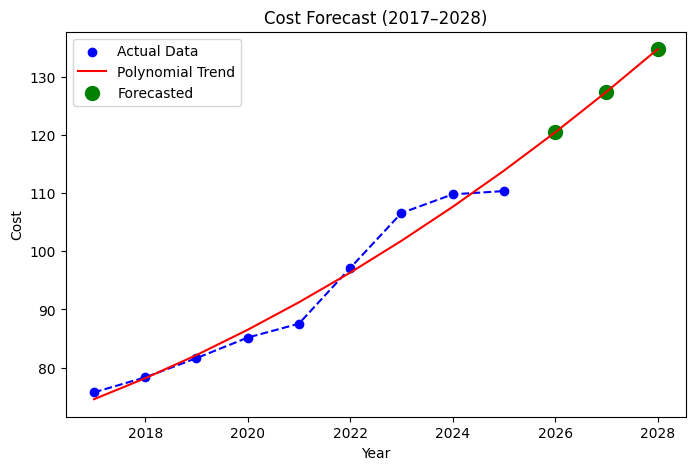

In [7]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Read Excel file
df = pd.read_excel("Forecast of the Dinner Meal.xlsx", sheet_name="Sheet1")

# --- Step 2: Prepare Data ---
X = df[['Year']]
y = df['Cost']

# Polynomial transformation (degree 2 for curved trend)
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

# --- Step 3: Fit Model ---
model = LinearRegression()
model.fit(X_poly, y)

# --- Step 4: Forecast future years ---
future_years = np.array([2026, 2027, 2028]).reshape(-1, 1)
future_X_poly = poly.transform(future_years)
future_costs = model.predict(future_X_poly)

# Combine predictions
forecast_df = pd.DataFrame({
    'Trend': [10, 11, 12],
    'Year': [2026, 2027, 2028],
    'Forecast_Cost': np.round(future_costs, 2)
})

print("Forecasted Costs:")
print(forecast_df)

# --- Step 5: Visualization ---
plt.figure(figsize=(8,5))
plt.scatter(df['Year'], df['Cost'], color='blue', label='Actual Data')
plt.plot(df['Year'], df['Cost'], color='blue', linestyle='dashed')

# Plot fitted line
years_full = np.arange(2017, 2029).reshape(-1, 1)
plt.plot(years_full, model.predict(poly.transform(years_full)), color='red', label='Polynomial Trend')

# Plot forecasted points
plt.scatter(forecast_df['Year'], forecast_df['Forecast_Cost'], color='green', marker='o', s=100, label='Forecasted')

plt.title('Cost Forecast (2017–2028)')
plt.xlabel('Year')
plt.ylabel('Cost')
plt.legend()
plt.grid(False)
plt.show()


In [5]:
import sys
print(sys.executable)


c:\Users\afeen\AppData\Local\Programs\Python\Python313\python.exe


In [11]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Read Excel file
df = pd.read_excel("Forecast of the Dinner Meal.xlsx", sheet_name="Sheet1")

# --- Step 2: Prepare Data ---
X = df[['Year']]
y = df['Cost']


import statsmodels.formula.api as smf
LinReg = smf.ols(formula = "Cost ~ Year", data = df).fit()

# Combine predictions
forecast_df = pd.DataFrame({
    'Trend': [10, 11, 12],
    'Year': [2026, 2027, 2028],
    'Forecast_Cost': np.round(future_costs, 2)
})

print("Forecasted Costs:")
print(forecast_df)

Forecasted Costs:
   Trend  Year  Forecast_Cost
0     10  2026         120.42
1     11  2027         127.38
2     12  2028         134.71


                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     148.8
Date:                Tue, 11 Nov 2025   Prob (F-statistic):           5.69e-06
Time:                        06:26:13   Log-Likelihood:                -21.868
No. Observations:                   9   AIC:                             47.74
Df Residuals:                       7   BIC:                             48.13
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -9825.2462    812.990    -12.085      0.0

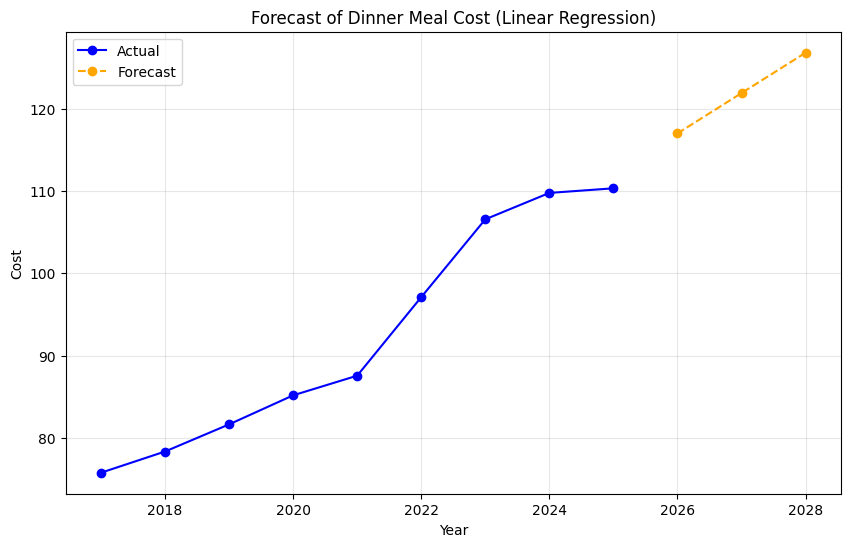

In [12]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Step 2: Load Data ---
df = pd.DataFrame({
    'Trend': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Year': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Cost': [75.76, 78.34, 81.64, 85.17, 87.56, 97.11, 106.57, 109.78, 110.34]
})

# --- Step 3: Fit Linear Regression Model ---
LinReg = smf.ols(formula="Cost ~ Year", data=df).fit()
print(LinReg.summary())

# --- Step 4: Forecast Future Years ---
future_years = pd.DataFrame({'Year': [2026, 2027, 2028]})
future_costs = LinReg.predict(future_years)

# --- Step 5: Combine Results ---
forecast_df = pd.DataFrame({
    'Trend': [10, 11, 12],
    'Year': [2026, 2027, 2028],
    'Forecast_Cost': np.round(future_costs, 2)
})

print("\nForecasted Costs:")
print(forecast_df)

# --- Step 6: Plot Actual vs Forecast ---
plt.figure(figsize=(10, 6))
plt.plot(df['Year'], df['Cost'], marker='o', label='Actual', color='blue')
plt.plot(future_years['Year'], future_costs, marker='o', linestyle='--', label='Forecast', color='orange')
plt.title("Forecast of Dinner Meal Cost (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     148.8
Date:                Tue, 11 Nov 2025   Prob (F-statistic):           5.69e-06
Time:                        06:28:10   Log-Likelihood:                -21.868
No. Observations:                   9   AIC:                             47.74
Df Residuals:                       7   BIC:                             48.13
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -9825.2462    812.990    -12.085      0.0

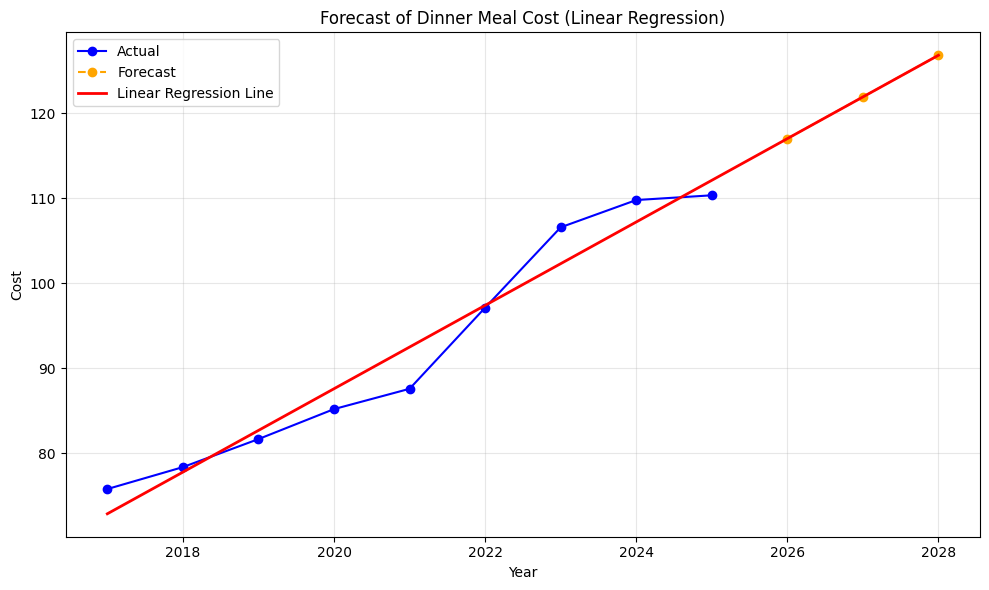

In [13]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Step 2: Load Data ---
df = pd.DataFrame({
    'Trend': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Year': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Cost': [75.76, 78.34, 81.64, 85.17, 87.56, 97.11, 106.57, 109.78, 110.34]
})

# --- Step 3: Fit Linear Regression Model ---
LinReg = smf.ols(formula="Cost ~ Year", data=df).fit()
print(LinReg.summary())

# --- Step 4: Forecast Future Years ---
future_years = pd.DataFrame({'Year': [2026, 2027, 2028]})
future_costs = LinReg.predict(future_years)

# --- Step 5: Combine Forecasts ---
forecast_df = pd.DataFrame({
    'Trend': [10, 11, 12],
    'Year': [2026, 2027, 2028],
    'Forecast_Cost': np.round(future_costs, 2)
})
print("\nForecasted Costs:")
print(forecast_df)

# --- Step 6: Create Continuous Regression Line ---
all_years = pd.DataFrame({'Year': np.arange(2017, 2029)})  # 2017–2028
predicted_line = LinReg.predict(all_years)

# --- Step 7: Plot Actual, Forecast, and Full Regression Line ---
plt.figure(figsize=(10, 6))

# Actual data points
plt.plot(df['Year'], df['Cost'], marker='o', color='blue', label='Actual')

# Forecasted data points
plt.plot(future_years['Year'], future_costs, marker='o', linestyle='--', color='orange', label='Forecast')

# Full regression line
plt.plot(all_years['Year'], predicted_line, color='red', linewidth=2, label='Linear Regression Line')

# Labels and styling
plt.title("Forecast of Dinner Meal Cost (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     148.8
Date:                Tue, 11 Nov 2025   Prob (F-statistic):           5.69e-06
Time:                        06:31:16   Log-Likelihood:                -21.868
No. Observations:                   9   AIC:                             47.74
Df Residuals:                       7   BIC:                             48.13
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -9825.2462    812.990    -12.085      0.0

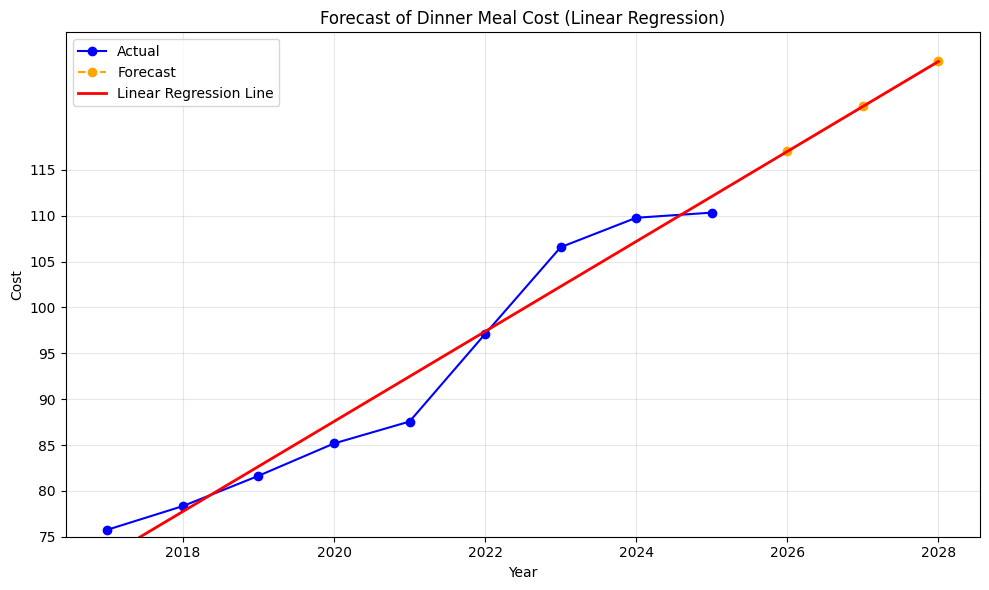

In [15]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Step 2: Load Data ---
df = pd.DataFrame({
    'Trend': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Year': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Cost': [75.76, 78.34, 81.64, 85.17, 87.56, 97.11, 106.57, 109.78, 110.34]
})

# --- Step 3: Fit Linear Regression Model ---
LinReg = smf.ols(formula="Cost ~ Year", data=df).fit()
print(LinReg.summary())

# --- Step 4: Forecast Future Years ---
future_years = pd.DataFrame({'Year': [2026, 2027, 2028]})
future_costs = LinReg.predict(future_years)

# --- Step 5: Combine Forecasts ---
forecast_df = pd.DataFrame({
    'Trend': [10, 11, 12],
    'Year': [2026, 2027, 2028],
    'Forecast_Cost': np.round(future_costs, 2)
})
print("\nForecasted Costs:")
print(forecast_df)

# --- Step 6: Create Continuous Regression Line ---
all_years = pd.DataFrame({'Year': np.arange(2017, 2029)})
predicted_line = LinReg.predict(all_years)

# --- Step 7: Plot Actual, Forecast, and Full Regression Line ---
plt.figure(figsize=(10, 6))

# Actual data points
plt.plot(df['Year'], df['Cost'], marker='o', color='blue', label='Actual')

# Forecasted data points
plt.plot(future_years['Year'], future_costs, marker='o', linestyle='--', color='orange', label='Forecast')

# Full regression line
plt.plot(all_years['Year'], predicted_line, color='red', linewidth=2, label='Linear Regression Line')

# --- Step 8: Set y-axis range and ticks ---
plt.ylim(75, 130)                            # set visible range
plt.yticks(np.arange(75, 120, 5))            # tick marks every 5 units

# Labels and styling
plt.title("Forecast of Dinner Meal Cost (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     148.8
Date:                Tue, 11 Nov 2025   Prob (F-statistic):           5.69e-06
Time:                        06:32:56   Log-Likelihood:                -21.868
No. Observations:                   9   AIC:                             47.74
Df Residuals:                       7   BIC:                             48.13
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -9825.2462    812.990    -12.085      0.0

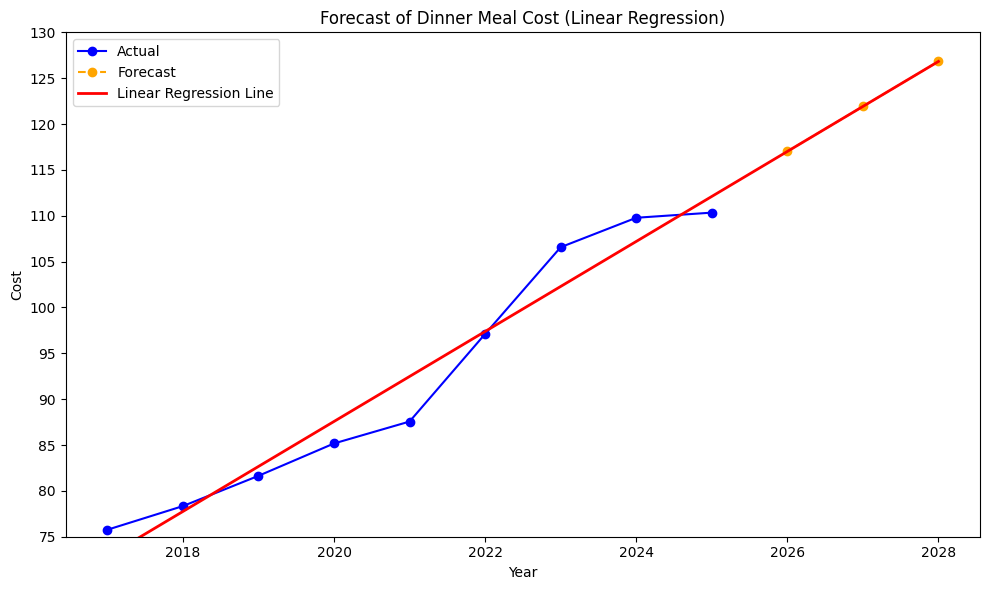

In [17]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Step 2: Load Data ---
df = pd.DataFrame({
    'Trend': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Year': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Cost': [75.76, 78.34, 81.64, 85.17, 87.56, 97.11, 106.57, 109.78, 110.34]
})

# --- Step 3: Fit Linear Regression Model ---
LinReg = smf.ols(formula="Cost ~ Year", data=df).fit()
print(LinReg.summary())

# --- Step 4: Forecast Future Years ---
future_years = pd.DataFrame({'Year': [2026, 2027, 2028]})
future_costs = LinReg.predict(future_years)

# --- Step 5: Combine Forecasts ---
forecast_df = pd.DataFrame({
    'Trend': [10, 11, 12],
    'Year': [2026, 2027, 2028],
    'Forecast_Cost': np.round(future_costs, 2)
})
print("\nForecasted Costs:")
print(forecast_df)

# --- Step 6: Create Continuous Regression Line ---
all_years = pd.DataFrame({'Year': np.arange(2017, 2029)})
predicted_line = LinReg.predict(all_years)

# --- Step 7: Plot Actual, Forecast, and Full Regression Line ---
plt.figure(figsize=(10, 6))

# Actual data points
plt.plot(df['Year'], df['Cost'], marker='o', color='blue', label='Actual')

# Forecasted data points
plt.plot(future_years['Year'], future_costs, marker='o', linestyle='--', color='orange', label='Forecast')

# Full regression line
plt.plot(all_years['Year'], predicted_line, color='red', linewidth=2, label='Linear Regression Line')

# --- Step 8: Set y-axis range and ticks ---
plt.ylim(75, 130)                            # set visible range from 75 to 130
plt.yticks(np.arange(75, 135, 5))            # tick marks every 5 units (up to 130)

# Labels and styling
plt.title("Forecast of Dinner Meal Cost (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.grid(True, alpha=0)
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     148.8
Date:                Tue, 11 Nov 2025   Prob (F-statistic):           5.69e-06
Time:                        06:50:04   Log-Likelihood:                -21.868
No. Observations:                   9   AIC:                             47.74
Df Residuals:                       7   BIC:                             48.13
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -9825.2462    812.990    -12.085      0.0

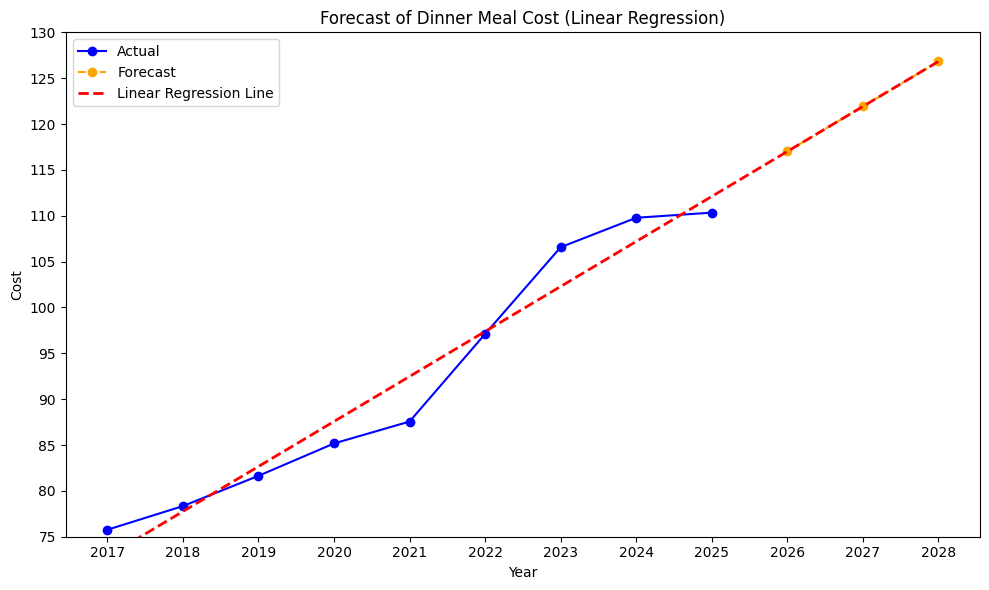

In [23]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Step 2: Load Data ---
df = pd.DataFrame({
    'Trend': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Year': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Cost': [75.76, 78.34, 81.64, 85.17, 87.56, 97.11, 106.57, 109.78, 110.34]
})

# --- Step 3: Fit Linear Regression Model ---
LinReg = smf.ols(formula="Cost ~ Year", data=df).fit()
print(LinReg.summary())

# --- Step 4: Forecast Future Years ---
future_years = pd.DataFrame({'Year': [2026, 2027, 2028]})
future_costs = LinReg.predict(future_years)

# --- Step 5: Combine Forecasts ---
forecast_df = pd.DataFrame({
    'Trend': [10, 11, 12],
    'Year': [2026, 2027, 2028],
    'Forecast_Cost': np.round(future_costs, 2)
})
print("\nForecasted Costs:")
print(forecast_df)

# --- Step 6: Create Continuous Regression Line ---
all_years = pd.DataFrame({'Year': np.arange(2017, 2029)})  # 2017–2028
predicted_line = LinReg.predict(all_years)

# --- Step 7: Plot Actual, Forecast, and Full Regression Line ---
plt.figure(figsize=(10, 6))

# Actual data points
plt.plot(df['Year'], df['Cost'], marker='o', color='blue', label='Actual')

# Forecasted data points (dashed line)
plt.plot(future_years['Year'], future_costs, marker='o', linestyle='--', color='orange', label='Forecast')

# Full regression line (solid)
plt.plot(all_years['Year'], predicted_line, linestyle='--', color='red', linewidth=2, label='Linear Regression Line')

# --- Step 8: Set y-axis range and ticks ---
plt.ylim(75, 130)
plt.yticks(np.arange(75, 135, 5))

# --- Step 9: Set x-axis to show every year ---
plt.xticks(np.arange(2017, 2029, 1))

# Labels and styling
plt.title("Forecast of Dinner Meal Cost (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


In [ ]:
# --- Step 7: Plot Actual, Forecast, and Full Regression Line ---
plt.figure(figsize=(10, 6))

# Actual data points
plt.plot(df['Year'], df['Cost'], marker='o', color='blue', label='Actual')

# Full regression line (solid for historical data)
plt.plot(all_years['Year'], predicted_line, color='red', linewidth=2, label='Linear Regression Line')

# Forecasted data (dashed line starting from last actual point)
forecast_line_years = np.array([2025, 2026, 2027, 2028])
forecast_line_values = LinReg.predict(pd.DataFrame({'Year': forecast_line_years}))
plt.plot(forecast_line_years, forecast_line_values, linestyle='--', color='orange', marker='o', label='Forecast')

# --- Step 8: Set y-axis range and ticks ---
plt.ylim(75, 130)
plt.yticks(np.arange(75, 135, 5))

# Labels and styling
plt.title("Forecast of Dinner Meal Cost (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     148.8
Date:                Tue, 11 Nov 2025   Prob (F-statistic):           5.69e-06
Time:                        19:23:45   Log-Likelihood:                -21.868
No. Observations:                   9   AIC:                             47.74
Df Residuals:                       7   BIC:                             48.13
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -9825.2462    812.990    -12.085      0.0

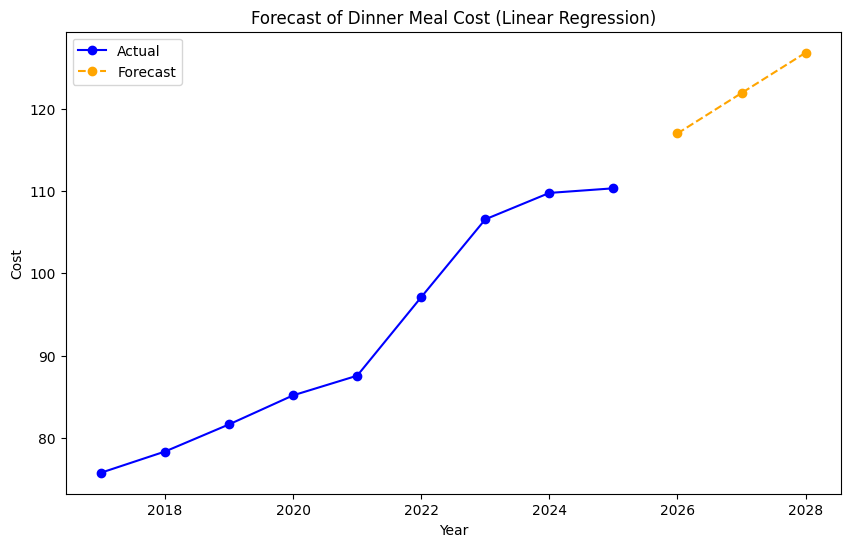

In [ ]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Step 2: Load Data ---
df = pd.DataFrame({
    'Trend': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Year': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Cost': [75.76, 78.34, 81.64, 85.17, 87.56, 97.11, 106.57, 109.78, 110.34]
})

# --- Step 3: Fit Linear Regression Model ---
LinReg = smf.ols(formula="Cost ~ Year", data=df).fit()
print(LinReg.summary())

# --- Step 4: Forecast Future Years ---
future_years = pd.DataFrame({'Year': [2026, 2027, 2028]})
future_costs = LinReg.predict(future_years)

# --- Step 5: Combine Results ---
forecast_df = pd.DataFrame({
    'Trend': [10, 11, 12],
    'Year': [2026, 2027, 2028],
    'Forecast_Cost': np.round(future_costs, 2)
})

print("\nForecasted Costs:")
print(forecast_df)

# --- Step 6: Plot Actual vs Forecast ---
plt.figure(figsize=(10, 6))
plt.plot(df['Year'], df['Cost'], marker='o', label='Actual', color='blue')
plt.plot(future_years['Year'], future_costs, marker='o', linestyle='--', label='Forecast', color='orange')
plt.title("Forecast of Dinner Meal Cost")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
#plt.grid(True, alpha=0.3)
plt.grid(False)
plt.show()

                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     148.8
Date:                Wed, 12 Nov 2025   Prob (F-statistic):           5.69e-06
Time:                        07:23:28   Log-Likelihood:                -21.868
No. Observations:                   9   AIC:                             47.74
Df Residuals:                       7   BIC:                             48.13
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -9825.2462    812.990    -12.085      0.0

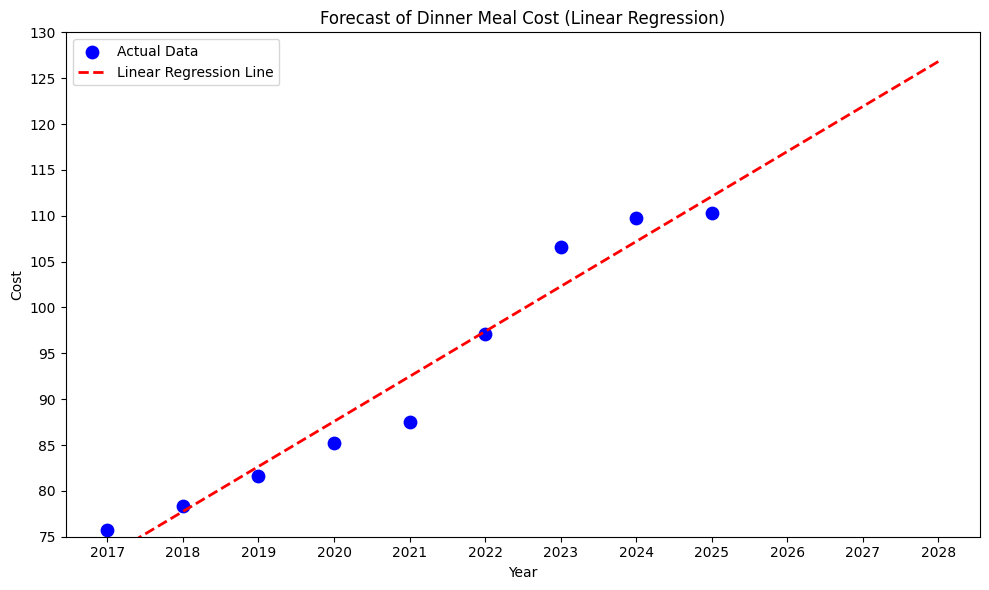

In [1]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Step 2: Load Data ---
df = pd.DataFrame({
    'Trend': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Year': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Cost': [75.76, 78.34, 81.64, 85.17, 87.56, 97.11, 106.57, 109.78, 110.34]
})

# --- Step 3: Fit Linear Regression Model ---
LinReg = smf.ols(formula="Cost ~ Year", data=df).fit()
print(LinReg.summary())

# --- Step 4: Create Continuous Regression Line (Actual + Future Years) ---
all_years = pd.DataFrame({'Year': np.arange(2017, 2029)})  # 2017–2028
predicted_line = LinReg.predict(all_years)

# --- Step 5: Plot Combined Chart ---
plt.figure(figsize=(10, 6))

# Actual data points
plt.scatter(df['Year'], df['Cost'], color='blue', label='Actual Data', s=80)

# Regression line running through and beyond data points
plt.plot(all_years['Year'], predicted_line, linestyle='--', color='red', linewidth=2, label='Linear Regression Line')

# --- Step 6: Styling ---
plt.ylim(75, 130)
plt.yticks(np.arange(75, 135, 5))
plt.xticks(np.arange(2017, 2029, 1))
plt.title("Forecast of Dinner Meal Cost (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     148.8
Date:                Wed, 12 Nov 2025   Prob (F-statistic):           5.69e-06
Time:                        07:24:33   Log-Likelihood:                -21.868
No. Observations:                   9   AIC:                             47.74
Df Residuals:                       7   BIC:                             48.13
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -9825.2462    812.990    -12.085      0.0

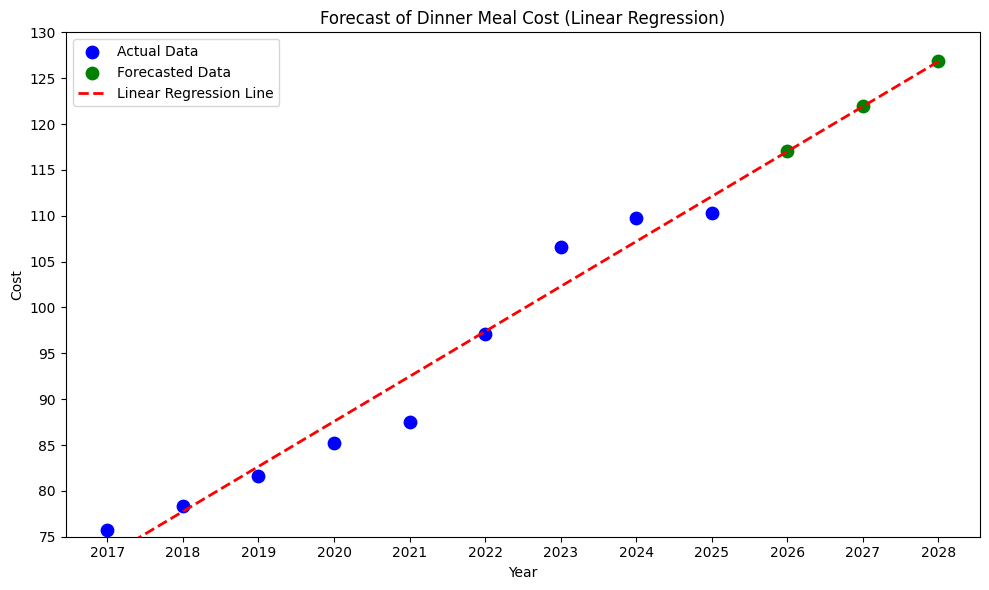

In [2]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Step 2: Load Data ---
df = pd.DataFrame({
    'Trend': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Year': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Cost': [75.76, 78.34, 81.64, 85.17, 87.56, 97.11, 106.57, 109.78, 110.34]
})

# --- Step 3: Fit Linear Regression Model ---
LinReg = smf.ols(formula="Cost ~ Year", data=df).fit()
print(LinReg.summary())

# --- Step 4: Forecast Future Years ---
future_years = pd.DataFrame({'Year': [2026, 2027, 2028]})
future_costs = LinReg.predict(future_years)

# --- Step 5: Create Continuous Regression Line (Actual + Future Years) ---
all_years = pd.DataFrame({'Year': np.arange(2017, 2029)})
predicted_line = LinReg.predict(all_years)

# --- Step 6: Plot Combined Chart ---
plt.figure(figsize=(10, 6))

# Actual data points (blue)
plt.scatter(df['Year'], df['Cost'], color='blue', label='Actual Data', s=80)

# Forecasted data points (green)
plt.scatter(future_years['Year'], future_costs, color='green', label='Forecasted Data', s=80)

# Regression line (red dashed)
plt.plot(all_years['Year'], predicted_line, linestyle='--', color='red', linewidth=2, label='Linear Regression Line')

# --- Step 7: Styling ---
plt.ylim(75, 130)
plt.yticks(np.arange(75, 135, 5))
plt.xticks(np.arange(2017, 2029, 1))
plt.title("Forecast of Dinner Meal Cost (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


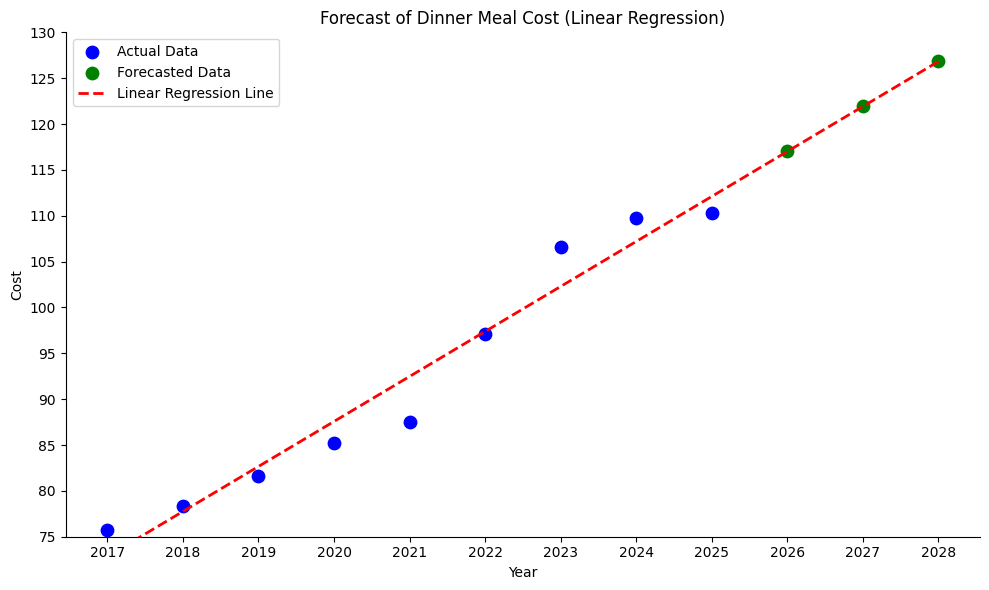

In [3]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Step 2: Load Data ---
df = pd.DataFrame({
    'Trend': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Year': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Cost': [75.76, 78.34, 81.64, 85.17, 87.56, 97.11, 106.57, 109.78, 110.34]
})

# --- Step 3: Fit Linear Regression Model ---
LinReg = smf.ols(formula="Cost ~ Year", data=df).fit()

# --- Step 4: Forecast Future Years ---
future_years = pd.DataFrame({'Year': [2026, 2027, 2028]})
future_costs = LinReg.predict(future_years)

# --- Step 5: Create Continuous Regression Line (Actual + Future Years) ---
all_years = pd.DataFrame({'Year': np.arange(2017, 2029)})
predicted_line = LinReg.predict(all_years)

# --- Step 6: Plot Combined Chart ---
plt.figure(figsize=(10, 6))

# Actual data points (blue)
plt.scatter(df['Year'], df['Cost'], color='blue', label='Actual Data', s=80)

# Forecasted data points (green)
plt.scatter(future_years['Year'], future_costs, color='green', label='Forecasted Data', s=80)

# Regression line (red dashed)
plt.plot(all_years['Year'], predicted_line, linestyle='--', color='red', linewidth=2, label='Linear Regression Line')

# --- Step 7: Styling ---
plt.ylim(75, 130)
plt.yticks(np.arange(75, 135, 5))
plt.xticks(np.arange(2017, 2029, 1))
plt.title("Forecast of Dinner Meal Cost (Linear Regression)")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()

# --- Keep only bottom and left axes ---
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.grid(False)
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     148.8
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           5.69e-06
Time:                        11:41:24   Log-Likelihood:                -21.868
No. Observations:                   9   AIC:                             47.74
Df Residuals:                       7   BIC:                             48.13
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -9825.2462    812.990    -12.085      0.0

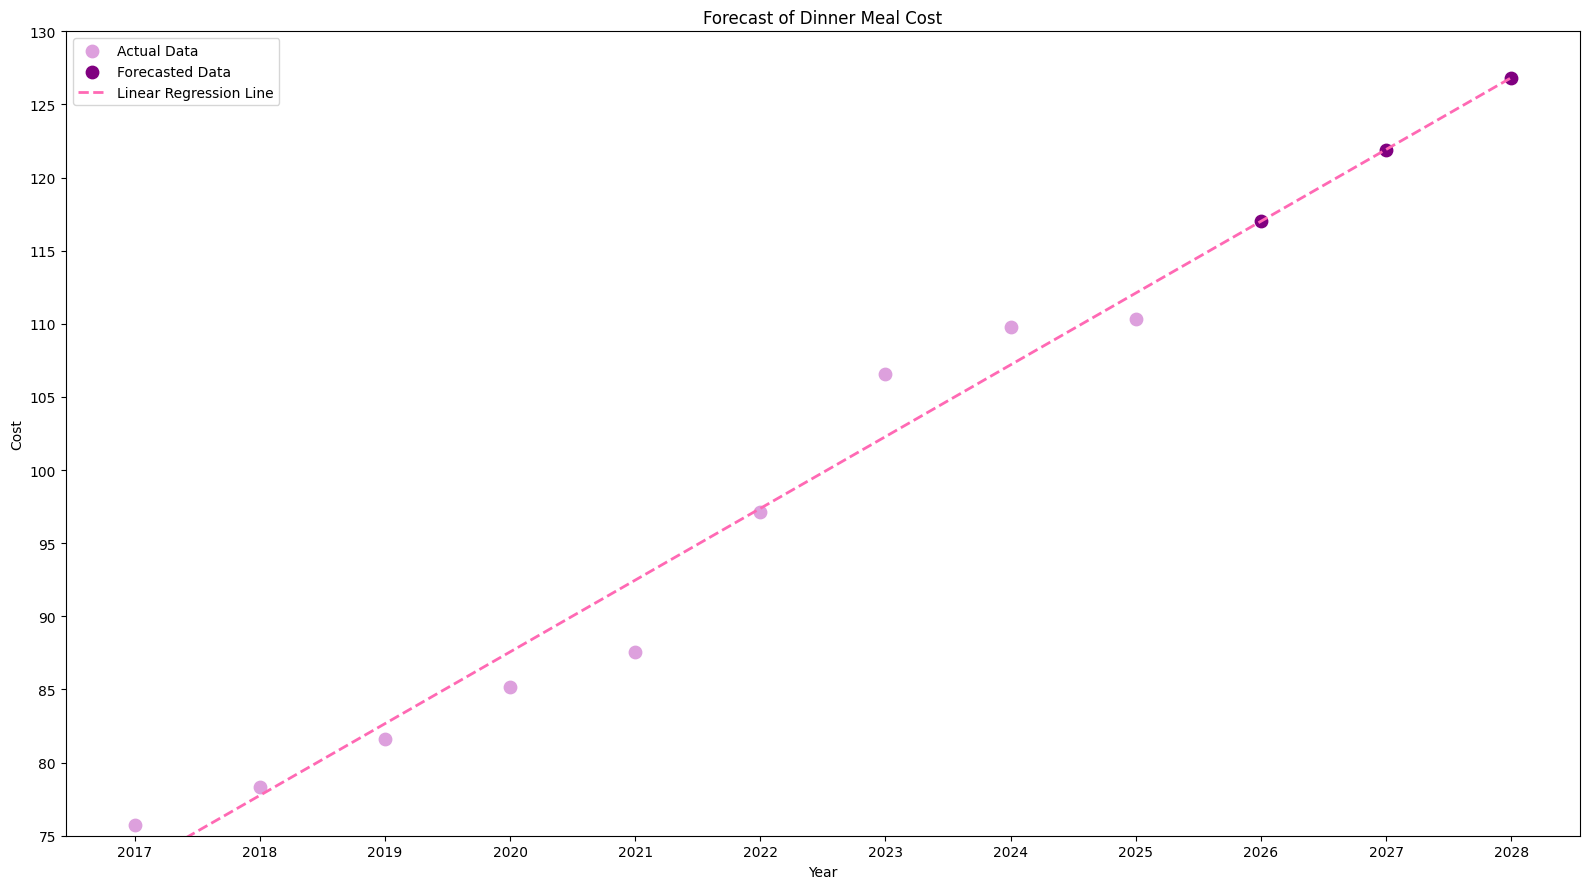

In [9]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Step 2: Load Data ---
df = pd.DataFrame({
    'Trend': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Year': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Cost': [75.76, 78.34, 81.64, 85.17, 87.56, 97.11, 106.57, 109.78, 110.34]
})

# --- Step 3: Fit Linear Regression Model ---
LinReg = smf.ols(formula="Cost ~ Year", data=df).fit()
print(LinReg.summary())

# --- Step 4: Forecast Future Years ---
future_years = pd.DataFrame({'Year': [2026, 2027, 2028]})
future_costs = LinReg.predict(future_years)

# --- Step 5: Create Continuous Regression Line (Actual + Future Years) ---
all_years = pd.DataFrame({'Year': np.arange(2017, 2029)})
predicted_line = LinReg.predict(all_years)

# --- Step 6: Plot Combined Chart ---
plt.figure(figsize=(16, 9))

# Actual data points (blue)
plt.scatter(df['Year'], df['Cost'], color='plum', label='Actual Data', s=80)

# Forecasted data points (green)
plt.scatter(future_years['Year'], future_costs, color='purple', label='Forecasted Data', s=80)

# Regression line (red dashed)
plt.plot(all_years['Year'], predicted_line, linestyle='--', color='hotpink', linewidth=2, label='Linear Regression Line')
plt.savefig("forecast_chart-burger.png", dpi=300, bbox_inches="tight")

# --- Step 7: Styling ---
plt.ylim(75, 130)
plt.yticks(np.arange(75, 135, 5))
plt.xticks(np.arange(2017, 2029, 1))
plt.title("Forecast of Dinner Meal Cost")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


                            OLS Regression Results                            
Dep. Variable:                   Cost   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.949
Method:                 Least Squares   F-statistic:                     148.8
Date:                Mon, 24 Nov 2025   Prob (F-statistic):           5.69e-06
Time:                        13:09:01   Log-Likelihood:                -21.868
No. Observations:                   9   AIC:                             47.74
Df Residuals:                       7   BIC:                             48.13
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -9825.2462    812.990    -12.085      0.0

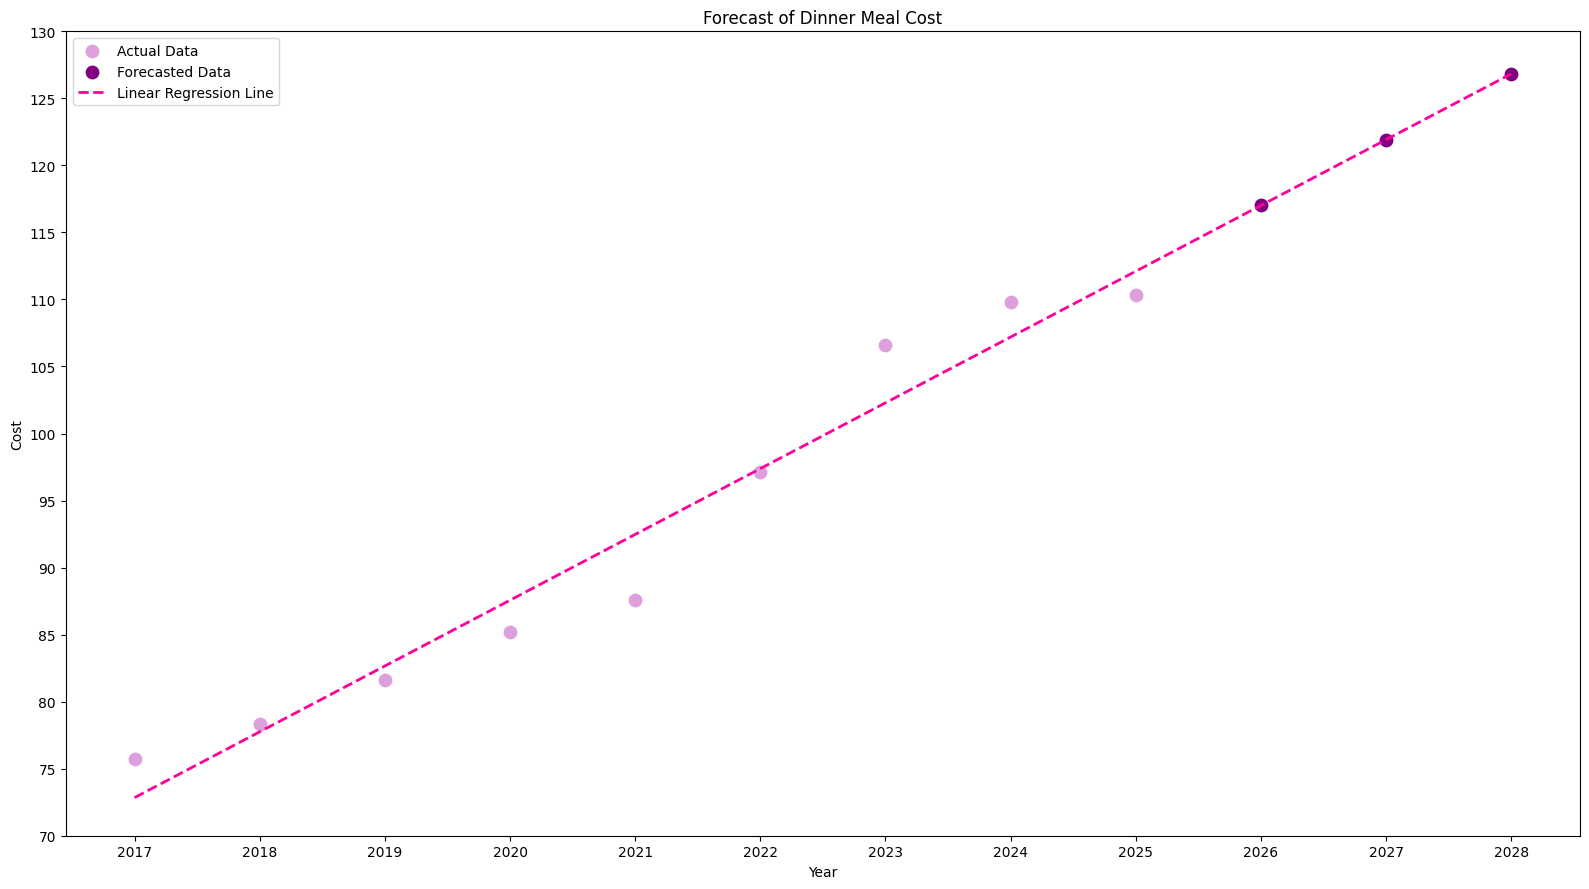

In [5]:
# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Step 2: Load Data ---
df = pd.DataFrame({
    'Trend': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Year': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Cost': [75.76, 78.34, 81.64, 85.17, 87.56, 97.11, 106.57, 109.78, 110.34]
})

# --- Step 3: Fit Linear Regression Model ---
LinReg = smf.ols(formula="Cost ~ Year", data=df).fit()
print(LinReg.summary())

# --- Step 4: Forecast Future Years ---
future_years = pd.DataFrame({'Year': [2026, 2027, 2028]})
future_costs = LinReg.predict(future_years)

# --- Step 5: Create Continuous Regression Line (Actual + Future Years) ---
all_years = pd.DataFrame({'Year': np.arange(2017, 2029)})
predicted_line = LinReg.predict(all_years)

# --- Step 6: Plot Combined Chart ---
plt.figure(figsize=(16, 9))

# Actual data points (blue)
plt.scatter(df['Year'], df['Cost'], color='plum', label='Actual Data', s=80)

# Forecasted data points (green)
plt.scatter(future_years['Year'], future_costs, color='purple', label='Forecasted Data', s=80)

# Regression line (red dashed)
plt.plot(all_years['Year'], predicted_line, linestyle='--', color='#ff0099', linewidth=2, label='Linear Regression Line')
plt.savefig("forecast_chart-burger.png", dpi=300, bbox_inches="tight")

# --- Step 7: Styling ---
plt.ylim(70, 130)
plt.yticks(np.arange(70, 135, 5))
plt.xticks(np.arange(2017, 2029, 1))
plt.title("Forecast of Dinner Meal Cost")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


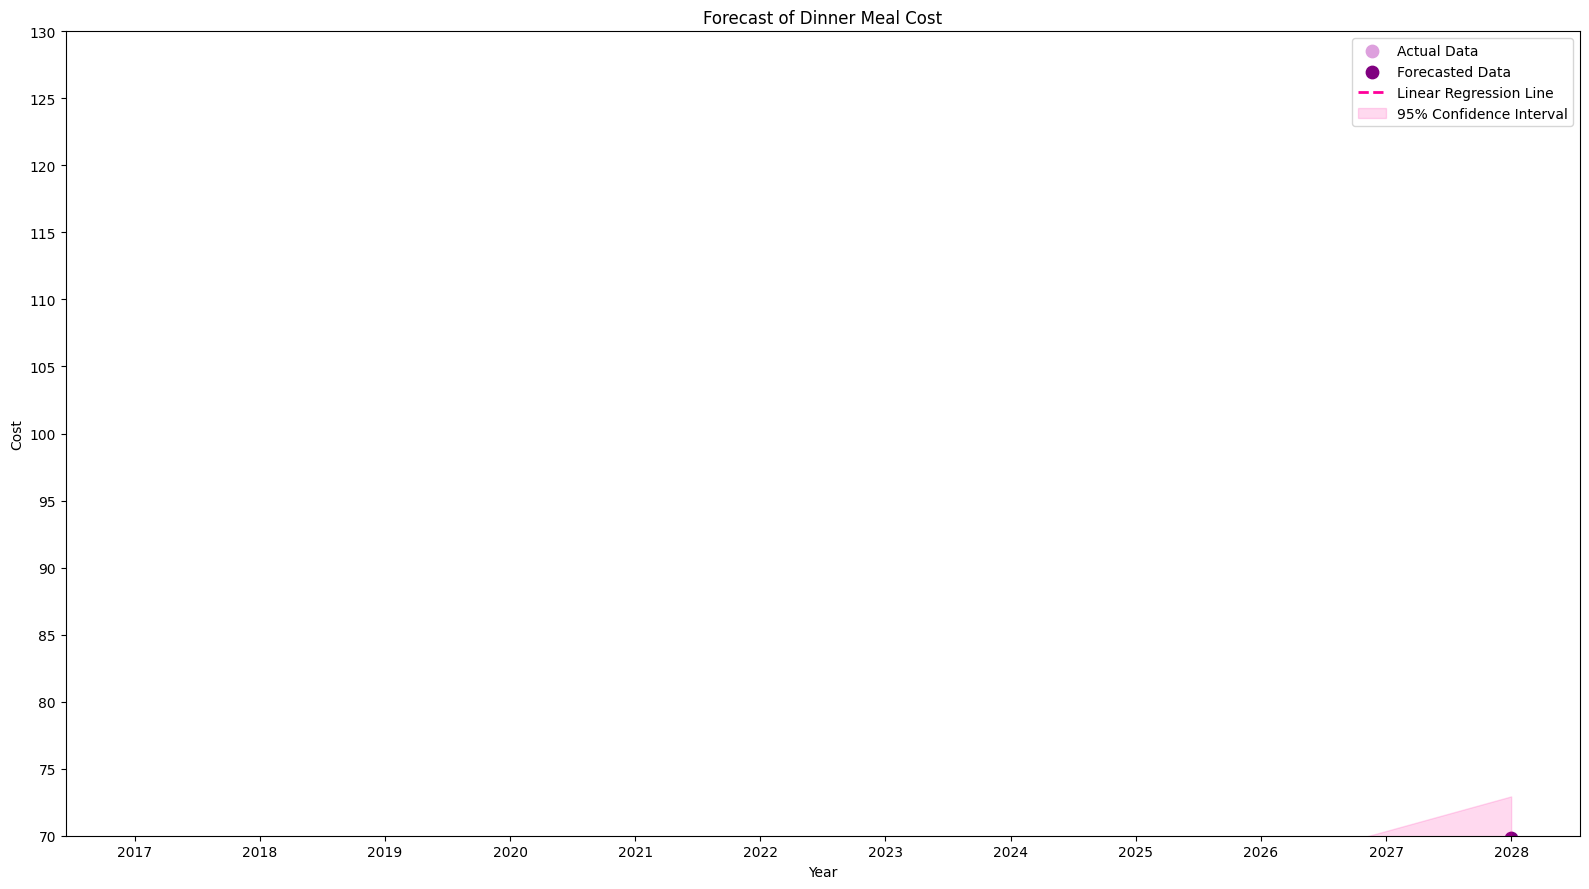

In [ ]:
# UNCERTAINTY CHART

# --- Step 1: Import Libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# --- Step 2: Load Data ---
df = pd.DataFrame({
    'Trend': [1, 2, 3, 4, 5, 6, 7, 8, 9],
    'Year': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Cost': [46.07, 47.65, 50.11, 52.8, 51.58, 58.18, 60.17, 60.62, 62.88]
})

# --- Step 3: Fit Linear Regression Model ---
LinReg = smf.ols(formula="Cost ~ Year", data=df).fit()

# --- Step 4: Forecast Future Years ---
future_years = pd.DataFrame({'Year': [2026, 2027, 2028]})
future_costs = LinReg.predict(future_years)

# --- Step 5: Create Continuous Regression Line (Actual + Future Years) ---
all_years = pd.DataFrame({'Year': np.arange(2017, 2029)})

# Prediction with confidence intervals
pred = LinReg.get_prediction(all_years)
pred_summary = pred.summary_frame(alpha=0.05)   # 95% CI

predicted_line = pred_summary['mean']
lower_ci = pred_summary['mean_ci_lower']
upper_ci = pred_summary['mean_ci_upper']

# --- Step 6: Plot Combined Chart ---
plt.figure(figsize=(16, 9))

# Actual data points
plt.scatter(df['Year'], df['Cost'], color='plum', s=80, label='Actual Data')

# Forecasted points
plt.scatter(future_years['Year'], future_costs, color='purple', s=80, label='Forecasted Data')

# Regression line (bright pink)
plt.plot(all_years['Year'], predicted_line,
         linestyle='--', color='#ff0099', linewidth=2,
         label='Linear Regression Line')

# Uncertainty band (light pink)
plt.fill_between(all_years['Year'], lower_ci, upper_ci,
                 color='#ff0099', alpha=0.15, label='95% Confidence Interval')

# --- Step 7: Styling ---
plt.ylim(70, 130)
plt.yticks(np.arange(70, 135, 5))
plt.xticks(np.arange(2017, 2029, 1))
plt.title("Forecast of Dinner Meal Cost")
plt.xlabel("Year")
plt.ylabel("Cost")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()
